# Sales Performence Analysis and Customer Behavior Insights

This project analyzes sales data to identify revenue trends,
customer behavior,andproduct performence 
to support better business decisions.

In [2]:
#Import/Inspect
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
df=pd.read_excel("C:/Users/HP/Downloads/Auto_sales.xlsm")
df.head(10)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2871.00,2018-02-24,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,2765.90,2018-05-07,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,3884.34,2018-07-01,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,3746.70,2018-08-25,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,3479.76,2018-10-28,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium
5,10180,29,86.13,2497.77,2018-11-11,573,Shipped,Motorcycles,95,S10_1678,Daedalus Designs Imports,"184, chausse de Tournai",Lille,59000,France,Rance,Martine,Small
6,10188,48,114.84,5512.32,2018-11-18,567,Shipped,Motorcycles,95,S10_1678,Herkku Gifts,"Drammen 121, PR 744 Sentrum",Bergen,N 5804,Norway,Oeztan,Veysel,Medium
7,10211,41,114.84,4708.44,2019-01-15,510,Shipped,Motorcycles,95,S10_1678,Auto Canal Petit,"25, rue Lauriston",Paris,75016,France,Perrier,Dominique,Medium
8,10223,37,107.18,3965.66,2019-02-20,475,Shipped,Motorcycles,95,S10_1678,"Australian Collectors, Co.",636 St Kilda Road,Melbourne,3004,Australia,Ferguson,Peter,Medium
9,10237,23,101.44,2333.12,2019-04-05,432,Shipped,Motorcycles,95,S10_1678,Vitachrome Inc.,2678 Kingston Rd.,NYC,10022,USA,Frick,Michael,Small


In [39]:
pd.options.display.float_format = '{:,.2f}'.format

In [40]:
print("shape:",df.shape)

shape: (2747, 21)


In [41]:
print(df.dtypes)

order_number                     int64
qty_ordered                      int64
PRICEEACH                      float64
SALES                          float64
ORDERDATE               datetime64[us]
DAYS_SINCE_LASTORDER             int64
STATUS                             str
PRODUCTLINE                        str
MSRP                             int64
PRODUCTCODE                        str
Customer Name                      str
ADDRESSLINE1                       str
CITY                               str
POSTALCODE                      object
COUNTRY                            str
CONTACTLASTNAME                    str
CONTACTFIRSTNAME                   str
DEALSIZE                           str
Year                             int32
Month                            int32
Revenue_per_item               float64
dtype: object


## Data Understanding

**Each row represents:**
Each row represent a single transaction entry for a product within an order.
A single order may contain multiple rows if multiple products are purchased.

**SALES:**
SALES represents the total revenue generated from each transaction.

**CUSTOMERNAME:**
CUSTOMERNAME represents the customer or organization placing 
the order.CONTACTFIRSTNAME AND CONTACTLASTNAMErefer
to the individual contact person.







**Shape:**
The dataset contains 2,747 rows and 20 columns. 
Each row represents a transaction-level 
record,including customer, product, and 
sales information,making it suitable 
for analyzing revenue trends and
customer behavior.








**Data Types:**
The dataset contains both numerical and categorical variables. Numerical columns
such as QUANTITYORDERED, PRICEEACH, and SALES represent transactional and
revenue-related values.Categorical columns such as STATUS,
PRODUCTLINE, and COUNTRY describe qualitative attributes
related to orders and customers.The ORDERDATE column
is in datetime format, which enables time-based 
analysis. Additionally, derived columns 
like Year and Month will help
in analyzing sales trends
over time.

## Data Cleaning

In [42]:
#3.Duplicates
print(df.duplicated().sum())

0


In [43]:
print(df.isnull().sum())

order_number            0
qty_ordered             0
PRICEEACH               0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
Customer Name           0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
Year                    0
Month                   0
Revenue_per_item        0
dtype: int64


In [44]:
#date time conversion
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
#column renaming
df.rename(columns={
    'ORDERNUMBER': 'order_number',
    'QUANTITYORDERED': 'qty_ordered',
    'CUSTOMERNAME': 'Customer Name'
}, inplace=True)

## Data Cleaning

*No duplicate records were found in the dataset, indicating that each transaction entry is unique.

*The dataset does not contain any missing values, which suggests good data quality and completeness for analysis.

*The ORDERDATE column was converted into datetime format to enable time-based analysis such as monthly and yearly trends.

*Column names were simplified for better readability and ease of analysis.

## Feature Engineering

In [45]:
#extracting year and month 
df['Year']=df['ORDERDATE'].dt.year
df['Month']=df['ORDERDATE'].dt.month
#Generating Revenue 
df['Revenue_per_item']=df['SALES']/df['qty_ordered']
df[['Year','Month','Revenue_per_item']].head()

,Year,Month,Revenue_per_item
0,2018,2,95.70
1,2018,5,81.35
2,2018,7,94.74
3,2018,8,83.26
4,2018,10,96.66


### Feature Engineering
New features were created to enhance the dataset for analysis. 
The Year and Month were extracted from the ORDERDATE column to 
analyze time-based trends in sales.Additionally,
a new feature called Revenue_per_item was created to 
understand the average revenue generated 
per item sold, which provides insight 
into pricing and sales patterns.

# Exploratory Data Analysis

## Time Based Analysis

### Yearly Revenue Analysis

In [46]:
Yearly_revenue_trend=df.groupby('Year',as_index=False)['SALES'].sum()
Yearly_revenue_trend

,Year,SALES
0,2018,"3,353,014.06"
1,2019,"4,669,924.56"
2,2020,"1,737,283.09"


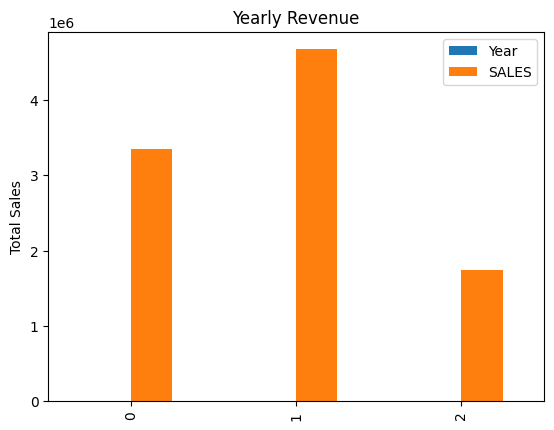

In [47]:
#Visualization
import matplotlib.pyplot as plt

Yearly_revenue_trend.plot(kind='bar')
plt.title('Yearly Revenue')
plt.ylabel('Total Sales')
plt.show()

#### Yearly Revenue Analysis Insigts 
The bar chart visualization clearly illustrates the yearly revenue trend. It highlights a steady growth in sales from 2018 to 2019,
followed by a noticeable decline in 2020.The visual representation makes it easier to identify the sharp drop in 2020, 
reinforcing the need for deeper investigation into potential causes such as seasonal patterns, customer behavior, 
or incomplete data.

### Monthly Revenue Analysis

In [48]:
Monthly_revenue_trend=df.groupby('Month',as_index=False)['SALES'].sum()
Monthly_revenue_trend

,Month,SALES
0,1,"761,985.12"
1,2,"756,238.28"
2,3,"735,805.81"
3,4,"669,390.96"
4,5,"923,972.56"
5,6,"454,756.78"
6,7,"514,875.97"
7,8,"659,310.57"
8,9,"584,724.27"
9,10,"1,001,377.20"


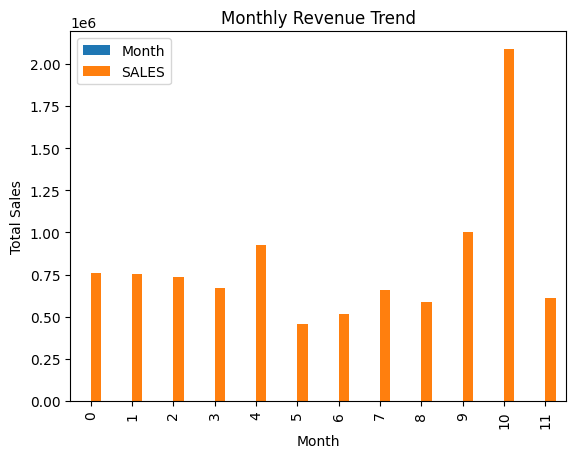

In [49]:
Monthly_revenue_trend.plot(kind='bar')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

#### Monthly Revenue Insights

The bar chart visualization of monthly revenue highlights clear variations in sales performance across different months.November emerges as the highest revenue-generating month, indicating a strong seasonal peak, possibly driven byfestive demand or promotional activities.
In contrast, June records the lowest sales, suggesting a period ofreduced customer activity. Overall, 
the visualization reveals a clear seasonal pattern, with higher revenues concentrated 
towards the later months of the year.

### Monthly Sales Trend by Year

In [50]:
monthly_year_sales_trend = df.groupby(['Year', 'Month'])['SALES'].sum().reset_index()


In [51]:
pivot_table = df.pivot_table(
    values='SALES',
    index='Month',
    columns='Year',
    aggfunc='sum'
)

pivot_table

Year,2018,2019,2020
Month,,,
1,"129,753.60","292,688.10","339,543.42"
2,"140,836.19","311,419.53","303,982.56"
3,"155,809.32","205,733.73","374,262.76"
4,"201,609.55","206,148.12","261,633.29"
5,"192,673.11","273,438.39","457,861.06"
6,"168,082.56","286,674.22",NaN
7,"187,731.88","327,144.09",NaN
8,"197,809.30","461,501.27",NaN
9,"263,973.36","320,750.91",NaN


#### Monthly Sales by year Table Insights
The monthly sales comparison across years reveals that data for 2020 is only available up to May,
with no records from June to December. This indicates that the dataset for 2020 is incomplete,
which explains the significant drop in yearly revenue observed earlier.
Therefore, the decline in 2020 sales should not be interpreted 
as an actual business performance issue
but rather as a limitation of the 
dataset.This highlights the importance of validating data 
completeness before drawing conclusions from analysis.

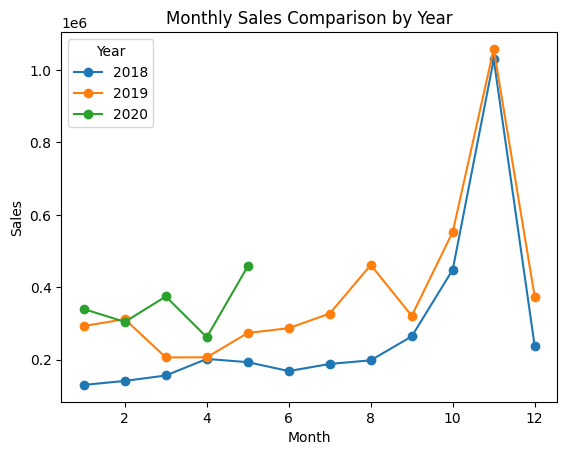

In [52]:
#Visualization
pivot_table.plot(marker='o')
plt.title('Monthly Sales Comparison by Year')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

#### Monthly Sales by Year Visualizatin Insights
The line chart visualization compares monthly sales trends across different years. It shows consistent patterns for 2018 and 2019 across all months. However, for 2020, the trend is visible only up to May, after which no data is present.


The time-based analysis reveals clear seasonal patterns in revenue, with sales peaking toward the end of the year, particularly in November. While both 2018 and 2019 follow consistent trends, the incomplete data for 2020 limits accurate comparison. Overall, the analysis emphasizes strong seasonality in sales and the need for complete data when evaluating year-over-year performance.

The time-based analysis reveals clear fluctuations in sales across different months and years, indicating the presence of seasonality in the business. Certain months consistently show higher sales volumes, suggesting periods of increased customer demand, possibly driven by promotional campaigns, holidays, or market cycles. Additionally, some months show missing or lower values, which may indicate incomplete data or operational slowdowns. Understanding these patterns allows the business to better plan inventory, staffing, and marketing efforts during peak and low-demand periods.

## Customer Analysis

### Top Customers by Revenue

In [53]:
top_customers = df.groupby('Customer Name')['SALES'].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Euro Shopping Channel          912,294.11
Mini Gifts Distributors Ltd.   654,858.06
Australian Collectors, Co.     200,995.41
Muscle Machine Inc             197,736.94
La Rochelle Gifts              180,124.90
Dragon Souveniers, Ltd.        172,989.68
Land of Toys Inc.              164,069.44
The Sharp Gifts Warehouse      160,010.27
AV Stores, Co.                 157,807.81
Anna's Decorations, Ltd        153,996.13
Name: SALES, dtype: float64

#### Customer Revenue Insights
The analysis reveals that revenue is highly concentrated among a few key customers,with Euro Shopping Channel being the top contributor by 
a significant margin. This indicates a dependency on high-value clients, which can pose a business risk if any of 
these customers reduce their purchases.At the same time, it highlights the importance of maintaining strong
relationships with these customers to ensure consistent revenue.

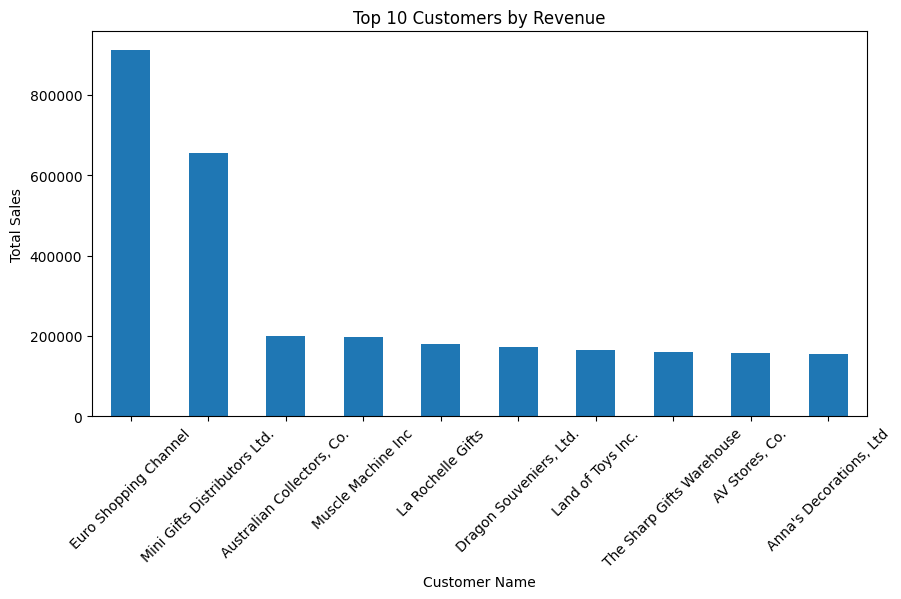

In [54]:
top_customers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

#### Top Customers Visulization Insights 
The chart highlights the top 10 customers based on total revenue contribution.
It clearly shows that a small number of customers generate
significantly higher sales compared to others,
with the leading customer contributing 
a substantially larger share.






The top three customers are organizations, suggesting that bulk purchasing by business clients significantly drives revenue. 
This highlights the importance of B2B relationships, as such customers tend to generate higher and more consistent sales compared to individual buyers.


#### Unique Customers

In [55]:
df['Customer Name'].nunique()

89

#### Repeated Customers

In [56]:
customer_orders = df.groupby('Customer Name')['order_number'].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

total = repeat_customers + one_time_customers

repeat_pct = (repeat_customers / total) * 100
one_time_pct = (one_time_customers / total) * 100

print(f"Repeat Customers: {repeat_customers} ({repeat_pct:.2f}%)")
print(f"One-time Customers: {one_time_customers} ({one_time_pct:.2f}%)")

Repeat Customers: 88 (98.88%)
One-time Customers: 1 (1.12%)


In [57]:
customer_orders.sort_values()

Customer Name
Bavarian Collectables Imports, Co.     1
Amica Models & Co.                     2
Auto Assoc. & Cie.                     2
Boards & Toys Co.                      2
CAF Imports                            2
                                      ..
Danish Wholesale Imports               5
Dragon Souveniers, Ltd.                5
Reims Collectables                     5
Mini Gifts Distributors Ltd.          17
Euro Shopping Channel                 26
Name: order_number, Length: 89, dtype: int64

In [58]:
customer_orders.value_counts().sort_index()

order_number
1      1
2     27
3     40
4     15
5      4
17     1
26     1
Name: count, dtype: int64

#### Customer Distribution 

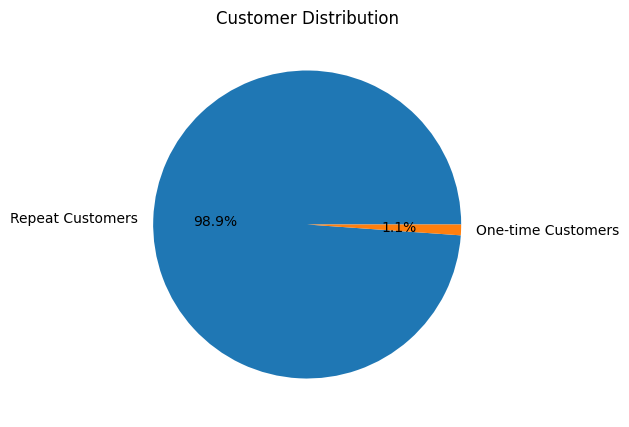

In [59]:

labels = ['Repeat Customers', 'One-time Customers']
values = [repeat_customers, one_time_customers]

plt.figure(figsize=(5,5))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Customer Distribution")
plt.show()

#### Repeated Customers Insights
The customer distribution shows that approximately 98.9% of customers are repeat buyers, while only 1.1% are one-time customers. This indicates exceptionally strong customer retention, suggesting that customers are highly satisfied and continue to make repeat purchases over time.

The extremely high proportion of repeat customers highlights a strong and loyal customer base. This suggests that the business benefits from consistent repeat purchases, which contributes to stable revenue generation. However, the very low number of one-time customers may also indicate limited new customer acquisition, pointing to an opportunity to expand the customer base.

The unusually high percentage of repeat customers may also reflect the nature of the dataset, where transactions are primarily recorded for existing clients. This should be considered while interpreting the results, as it may not fully represent new customer acquisition trends.


The visualization highlights that the vast majority of customers are repeat buyers, demonstrating a high level of customer retention. This indicates that the business has successfully built long-term relationships with its customers, leading to consistent repeat purchases. However, the very small proportion of one-time customers may also suggest limited new customer acquisition, pointing to an opportunity for growth.

#### Order Frequency Insights

In [60]:
order_frequency = df.groupby('Customer Name')['order_number'].nunique() \
                    .sort_values()

order_frequency

Customer Name
Bavarian Collectables Imports, Co.     1
Amica Models & Co.                     2
Auto Assoc. & Cie.                     2
Boards & Toys Co.                      2
CAF Imports                            2
                                      ..
Danish Wholesale Imports               5
Dragon Souveniers, Ltd.                5
Reims Collectables                     5
Mini Gifts Distributors Ltd.          17
Euro Shopping Channel                 26
Name: order_number, Length: 89, dtype: int64

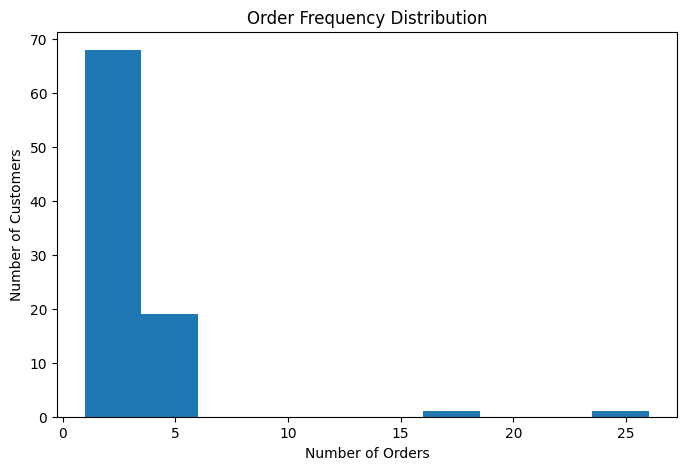

In [61]:
order_frequency.plot(kind='hist', bins=10, figsize=(8,5))
plt.title("Order Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

#### Order Frequency Insights
The histogram shows that most customers place a low number of orders, primarily between 1 and 5. Only a few customers have a significantly higher number of orders, indicating uneven purchasing behavior across the customer base.

The distribution is heavily right-skewed, with the majority of customers making only a few purchases while a small number of customers exhibit very high order frequency. This suggests that a limited group of highly engaged customers contributes disproportionately to overall transactions.

The histogram reveals a classic long-tail distribution, where most customers are low-frequency buyers and a small segment represents high-frequency customers. These high-value customers are critical to business performance and should be prioritized through retention strategies, loyalty programs, and personalized engagement. At the same time, the large base of low-frequency customers presents an opportunity for conversion into repeat buyers.


Customer analysis shows a highly skewed distribution of order frequency, where the majority of customers place a small number of orders, while a limited group of customers contributes significantly through repeated purchases. This indicates the presence of a loyal customer segment that drives consistent revenue, alongside a large base of low-engagement customers. Such a pattern is typical in many businesses, where a minority of customers generate a disproportionate share of revenue.

#### Revenue Contribution

In [62]:
customer_sales = df.groupby('Customer Name')['SALES'].sum() \
                   .sort_values(ascending=False)

top_10_contribution = customer_sales.head(10).sum()
total_sales = customer_sales.sum()

contribution_pct = (top_10_contribution / total_sales) * 100

print(f"Top 10 Customers Contribution: {contribution_pct:.2f}%")

Top 10 Customers Contribution: 30.27%


In [66]:
total_sales = df['SALES'].sum()

top10_sales = (
    df.groupby('Customer Name')['SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sum()
)

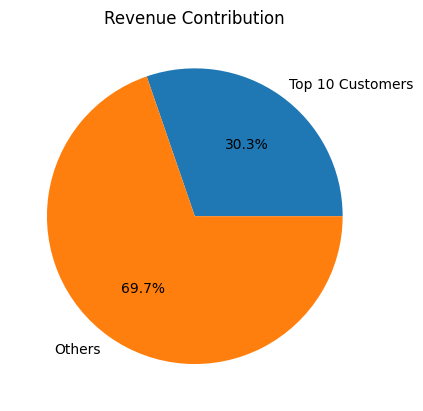

In [67]:
labels = ['Top 10 Customers', 'Others']
values = [top10_sales, total_sales - top10_sales]

plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Revenue Contribution")
plt.show()

#### Revenue Contribution

The revenue contribution chart shows that the top 10 customers account for approximately 30.3% of total sales, while the remaining 69.7% comes from the rest of the customer base. This indicates a balanced revenue distribution, where the business benefits from both high-value customers and a broad customer base. Such a structure reduces dependency risk and ensures more stable revenue generation.


The top 10 customers contribute approximately 30% of total revenue, indicating a moderately concentrated revenue structure. While these high-value customers are crucial for business performance, the majority of revenue still comes from the broader customer base. This balanced distribution reduces the risk of over-dependence on a few customers while highlighting the importance of maintaining strong relationships with key accounts.



The analysis of repeat versus one-time customers indicates a strong retention pattern, with most customers engaging in multiple transactions. This suggests that the business is successful in maintaining customer relationships and encouraging repeat purchases. However, there remains an opportunity to further improve engagement among low-frequency customers and convert them into loyal buyers.

#### Product Analysis

In [71]:
top_products = df.groupby('PRODUCTCODE')['SALES'].sum().sort_values(ascending=False).head(10)

top_products

PRODUCTCODE
S18_3232   284,249.02
S10_1949   179,815.23
S12_1108   168,585.32
S10_4698   158,202.48
S18_2238   154,623.95
S12_3891   145,332.04
S18_1662   139,421.97
S24_3856   135,859.20
S18_4027   133,779.35
S12_1666   130,466.79
Name: SALES, dtype: float64

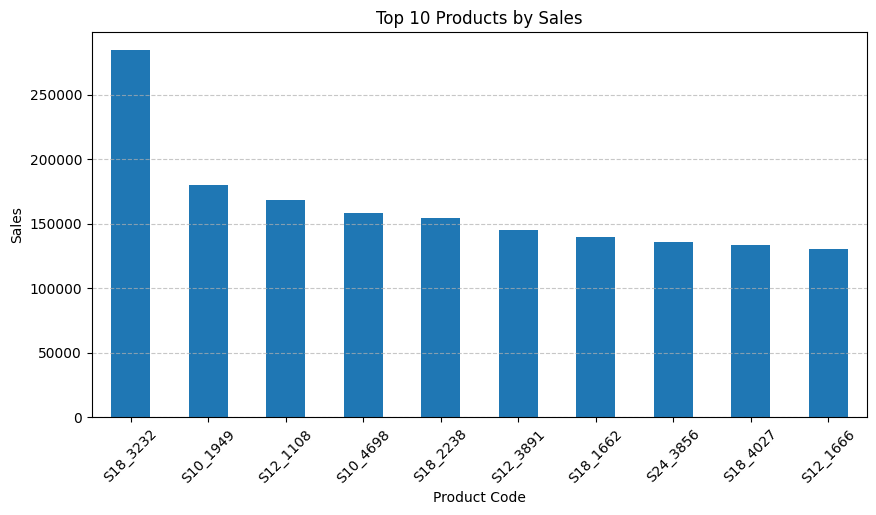

In [74]:
plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Code")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Product Analysis
The analysis of product performance shows that product S18_3232 is the top-selling item, generating the highest revenue among all products. The top 10 products contribute significantly to overall sales, indicating that certain products consistently outperform others. This highlights the presence of high-demand products that play a crucial role in driving business revenue.


The gap between the leading product and the rest indicates varying demand levels across the product portfolio. While high-performing products should be leveraged for consistent revenue, mid-performing products present opportunities for growth through targeted promotions, bundling strategies, and pricing optimization.


The distribution suggests a moderate concentration of revenue among top-performing products. These products act as key revenue drivers and should be prioritized for inventory management and marketing efforts. Ensuring their availability and visibility can directly impact sales performance.
The bar chart highlights the top 10 products by sales, with product S18_3232 clearly leading as the highest revenue generator. There is a noticeable drop from the top product to the others, followed by a relatively gradual decline among the remaining products. This indicates that while one product dominates, several other products also contribute significantly to overall revenue.


The product-level analysis highlights that a select group of products generates a significant portion of total sales. The leading product stands out with notably higher revenue compared to others, followed by a gradual decline among the remaining top-performing products. This indicates that certain products are highly preferred by customers and act as key revenue drivers for the business.


#### Product Line Analysis

In [76]:
product_line_sales = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

product_line_sales

PRODUCTLINE
Classic Cars       3,842,868.54
Vintage Cars       1,806,675.68
Trucks and Buses   1,111,559.19
Motorcycles        1,103,512.19
Planes               969,323.42
Ships                700,039.22
Trains               226,243.47
Name: SALES, dtype: float64

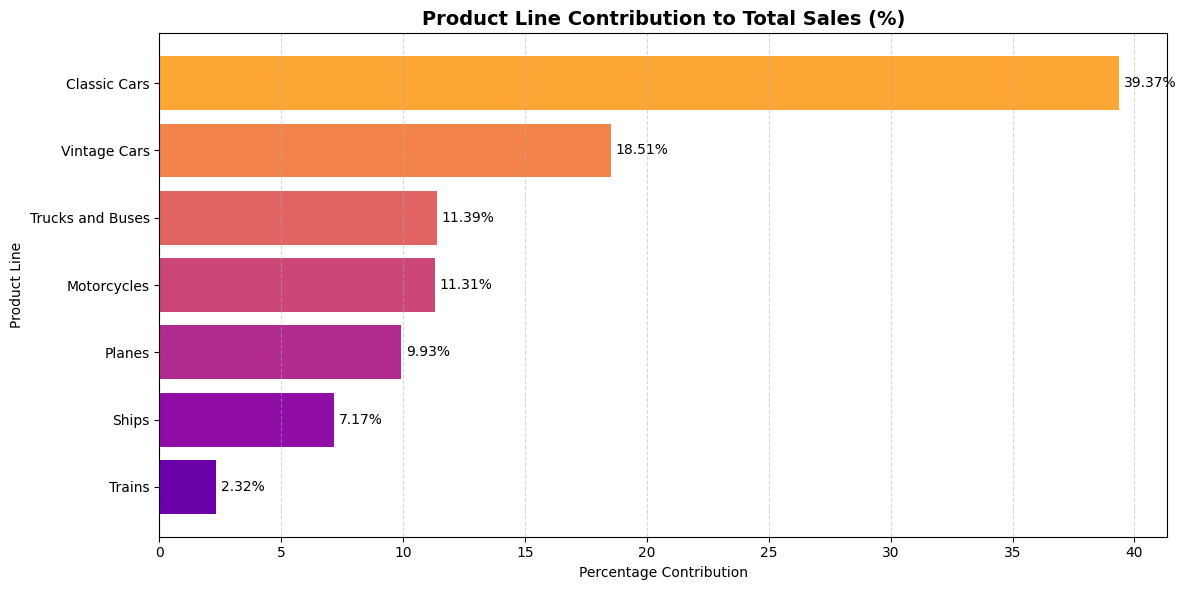

In [83]:
import matplotlib.pyplot as plt
import numpy as np

product_line_sales = df.groupby('PRODUCTLINE')['SALES'].sum()
percentage = (product_line_sales / product_line_sales.sum()) * 100

percentage = percentage.sort_values()

colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(percentage)))

plt.figure(figsize=(12,6))
plt.barh(percentage.index, percentage.values, color=colors)

for i, v in enumerate(percentage.values):
    plt.text(v + 0.2, i, f"{v:.2f}%", va='center')

plt.title("Product Line Contribution to Total Sales (%)", fontsize=14, fontweight='bold')
plt.xlabel("Percentage Contribution")
plt.ylabel("Product Line")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


#### Product line Analysis
Analysis at the product line level shows that revenue is unevenly distributed across categories, with some product lines contributing significantly more than others. This suggests that customer demand is concentrated in specific product categories, making them critical for overall business performance. Understanding these differences allows the company to prioritize high-performing product lines while identifying underperforming ones for improvement.
Some products have
      Better demand
      pricing
      Higher popularity

#### Country/Region Analysis 

In [84]:
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(10)

country_sales

COUNTRY
USA         3,355,575.69
Spain       1,215,686.92
France      1,110,916.52
Australia     630,623.10
UK            478,880.46
Italy         374,674.31
Finland       329,581.91
Norway        307,463.70
Singapore     288,488.41
Denmark       245,637.15
Name: SALES, dtype: float64

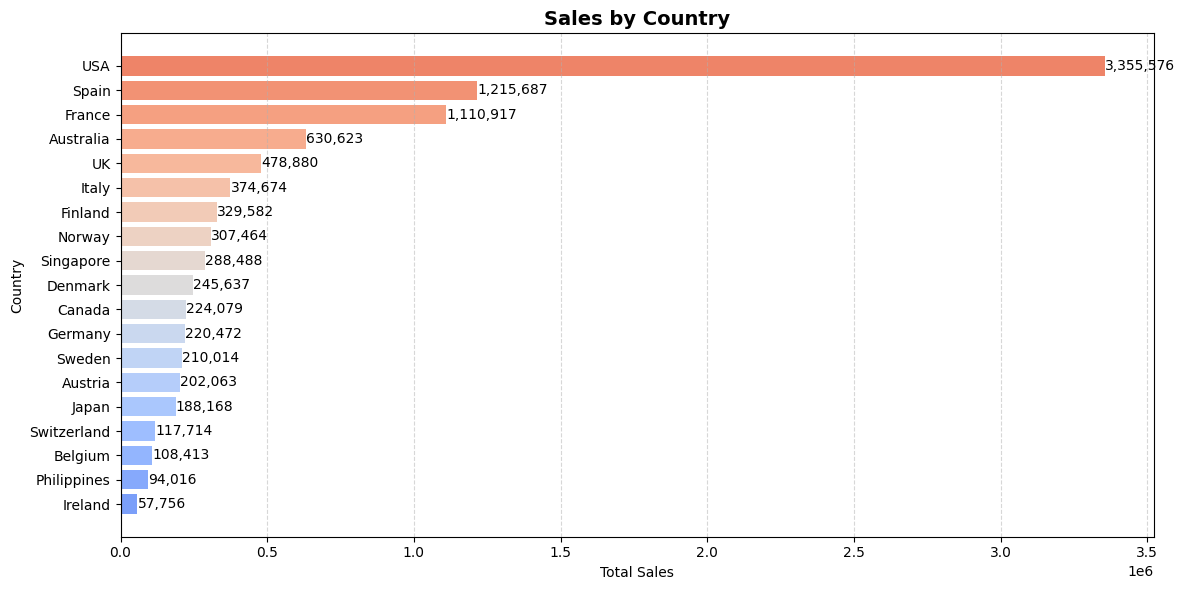

In [85]:
import matplotlib.pyplot as plt
import numpy as np

country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values()

colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(country_sales)))

plt.figure(figsize=(12,6))
plt.barh(country_sales.index, country_sales.values, color=colors)

# Add labels
for i, v in enumerate(country_sales.values):
    plt.text(v, i, f"{v:,.0f}", va='center')

plt.title("Sales by Country", fontsize=14, fontweight='bold')
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Geographical Analysis
The geographical analysis reveals that the USA is the dominant market, contributing a significantly higher share of total sales compared to other countries. European markets such as Spain and France serve as strong secondary contributors, while the remaining countries represent smaller but important segments of the business. This distribution indicates a well-established presence in key regions, along with opportunities to expand in emerging markets.

#### Deal Size Analysis

In [86]:
deal_size_sales = df.groupby('DEALSIZE')['SALES'].sum()

deal_size_sales

DEALSIZE
Large    1,258,956.40
Medium   5,931,231.47
Small    2,570,033.84
Name: SALES, dtype: float64

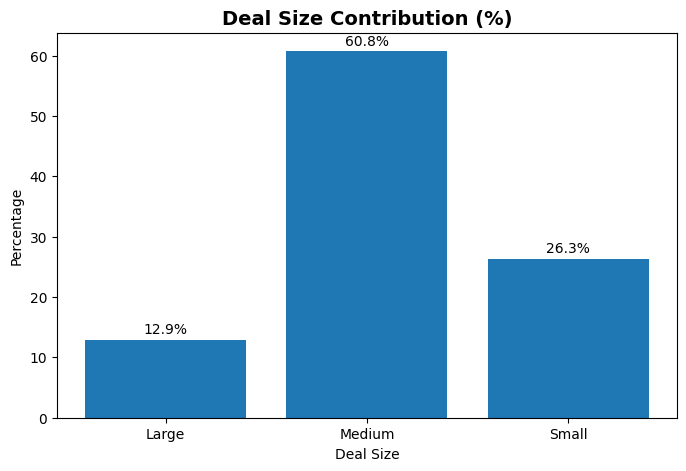

In [87]:
import matplotlib.pyplot as plt

deal_size_sales = df.groupby('DEALSIZE')['SALES'].sum()
percentage = (deal_size_sales / deal_size_sales.sum()) * 100

plt.figure(figsize=(8,5))
plt.bar(deal_size_sales.index, percentage.values)

for i, v in enumerate(percentage.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title("Deal Size Contribution (%)", fontsize=14, fontweight='bold')
plt.ylabel("Percentage")
plt.xlabel("Deal Size")

plt.show()

#### Deal size Analysis
The deal size analysis indicates that medium-sized deals contribute the largest portion of total revenue, significantly outperforming both small and large deals. Small deals provide consistent transaction volume, while large deals contribute relatively less, suggesting limited engagement in high-value transactions. This reflects a business model that relies primarily on mid-range sales rather than bulk or enterprise-level deals.

### Final Buisness Insights

#### Time based Analysis
The time-based analysis reveals clear fluctuations in sales across different months and years, indicating the presence of seasonality in the business. Certain months consistently show higher sales volumes, suggesting periods of increased customer demand, possibly driven by promotional campaigns, holidays, or market cycles. Additionally, some months show missing or lower values, which may indicate incomplete data or operational slowdowns. Understanding these patterns allows the business to better plan inventory, staffing, and marketing efforts during peak and low-demand periods.



#### Customer Behavior Analysis
Customer analysis shows a highly skewed distribution of order frequency, where the majority of customers place a small number of orders, while a limited group of customers contributes significantly through repeated purchases. This indicates the presence of a loyal customer segment that drives consistent revenue, alongside a large base of low-engagement customers. Such a pattern is typical in many businesses, where a minority of customers generate a disproportionate share of revenue.

##### Top 10 Customers
The top 10 customers contribute approximately 30% of total revenue, indicating a moderately concentrated revenue structure. While these high-value customers are crucial for business performance, the majority of revenue still comes from the broader customer base. This balanced distribution reduces the risk of over-dependence on a few customers while highlighting the importance of maintaining strong relationships with key accounts.
##### Repeated Customers
The analysis of repeat versus one-time customers indicates a strong retention pattern, with most customers engaging in multiple transactions. This suggests that the business is successful in maintaining customer relationships and encouraging repeat purchases. However, there remains an opportunity to further improve engagement among low-frequency customers and convert them into loyal buyers.


#### Product Analysis
The product-level analysis highlights that a select group of products generates a significant portion of total sales. The leading product stands out with notably higher revenue compared to others, followed by a gradual decline among the remaining top-performing products. This indicates that certain products are highly preferred by customers and act as key revenue drivers for the business.


##### Product line Analysis
Analysis at the product line level shows that revenue is unevenly distributed across categories, with some product lines contributing significantly more than others. This suggests that customer demand is concentrated in specific product categories, making them critical for overall business performance. Understanding these differences allows the company to prioritize high-performing product lines while identifying underperforming ones for improvement.


#### Geographical Analysis
The geographical analysis reveals that the USA is the dominant market, contributing a significantly higher share of total sales compared to other countries. European markets such as Spain and France serve as strong secondary contributors, while the remaining countries represent smaller but important segments of the business. This distribution indicates a well-established presence in key regions, along with opportunities to expand in emerging markets.


#### Deal Size Analysis
The deal size analysis indicates that medium-sized deals contribute the largest portion of total revenue, significantly outperforming both small and large deals. Small deals provide consistent transaction volume, while large deals contribute relatively less, suggesting limited engagement in high-value transactions. This reflects a business model that relies primarily on mid-range sales rather than bulk or enterprise-level deals.


#### Revenue Distribution
The overall revenue distribution demonstrates a balanced structure, where both high-value customers and a broad customer base contribute to total sales. While top customers and products play a significant role, the business is not overly dependent on any single entity. This diversification reduces risk and supports stable revenue generation over time.

### Risks
Despite strong performance, the business faces certain risks, including reliance on a dominant market such as the USA and dependence on a limited number of top-performing products and customers. Additionally, the relatively low contribution from large deals may limit opportunities for rapid revenue growth. Addressing these risks is essential for long-term sustainability.

#### Opportunities
The analysis highlights several growth opportunities, including expanding into underperforming geographic markets, increasing the share of high-value transactions, and improving the performance of lower-performing products. Enhancing customer engagement strategies to convert low-frequency buyers into repeat customers can further strengthen revenue streams and business growth.



## Final Business Conclusion
Overall, the business demonstrates a strong and stable performance driven by loyal customers, high-demand products, and a well-established primary market. However, there are clear opportunities to enhance growth by diversifying geographically, optimizing product performance, and increasing high-value transactions. By leveraging these insights, the business can improve efficiency, reduce risk, and achieve sustainable long-term growth.
